## Are the enriched GO terms driven by the GC bias, or orthogonal to it?

`goseq` (Young et al. 2010) corrects GO enrichment for a covariate bias. We use **GC content**
as the bias: it fits a probability weighting function `P(gene is DE | GC)`, then tests each term
with a **Wallenius non-central hypergeometric** test whose odds come from the PWF, inflating the
null for terms full of GC-extreme genes.

For each side of each comparison we compute both the **naive** (`method="Hypergeometric"`) and the
**GC-corrected** (`method="Wallenius"`) enrichment, then classify every term:
- **GC-robust** — significant under both → enrichment is *orthogonal* to the GC bias.
- **GC-driven** — significant naively but not after correction → a GC artifact.

This runs across **all three human comparisons** (10XvParse, 10XvPolyT, PolyTvRandO). Gene→category
membership is rebuilt from the same Enrichr **GO** libraries the enrichment used, and BH correction
is applied *within each ontology*. Results are written to each comparison's
`{side}_outliers/goseq_gc_corrected.csv`; render them with `plotting.plot_goseq_enrichment_bar`
(same style as the enrichr bar plot).

> Prereqs: each comparison folder must hold a **current** `results.csv` (re-run its
> `human_edgepy.ipynb` if unsure), and fetching the Enrichr GMTs needs network.

In [17]:
library(goseq)

# --- Rebuild the GO gene sets used for the enrichment as a gene->category map ---
LIBRARIES <- c("GO_Biological_Process_2026", "GO_Molecular_Function_2026",
               "GO_Cellular_Component_2026")

fetch_enrichr_gmt <- function(lib) {
  u <- paste0("https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=", lib)
  con <- url(u); on.exit(close(con))
  parts <- strsplit(readLines(con, warn = FALSE), "\t")
  do.call(rbind, lapply(parts, function(p) {
    genes <- p[-(1:2)]                          # cols 1-2 are the term name + description
    genes <- toupper(sub(",.*$", "", genes[genes != ""]))   # drop any ",weight" suffix
    if (length(genes) == 0) return(NULL)
    data.frame(gene = genes, category = paste0(lib, "::", p[1]), stringsAsFactors = FALSE)
  }))
}

gene2cat <- unique(do.call(rbind, lapply(LIBRARIES, fetch_enrichr_gmt)))
cat(sprintf("gene2cat: %d categories, %d genes, %d edges\n",
            length(unique(gene2cat$category)), length(unique(gene2cat$gene)), nrow(gene2cat)))

gene2cat: 7858 categories, 17097 genes, 279862 edges


In [18]:
# --- Config + helpers to run goseq for any comparison ---
GC_COL <- "gc_median_tx"; FDR <- 0.01
GM <- read.csv("/home/mcaskey/10XvParse/Notebooks/gene_info/human/gene_metrics_detailed.csv",
                stringsAsFactors = FALSE)
GM$gene <- toupper(GM$gene_name)

# Wallenius (GC-corrected) + Hypergeometric (naive) for one DE gene set; BH within each ontology.
run_goseq_side <- function(res, gene2cat, de_mask) {
  de <- as.integer(de_mask); names(de) <- res$gene
  pwf <- nullp(de, bias.data = res[[GC_COL]], plot.fit = FALSE)   # PWF: P(DE | GC)
  wal <- goseq(pwf, gene2cat = gene2cat)                              # GC-corrected
  hyp <- goseq(pwf, gene2cat = gene2cat, method = "Hypergeometric")  # naive
  m <- merge(wal[, c("category", "over_represented_pvalue", "numDEInCat", "numInCat")],
             hyp[, c("category", "over_represented_pvalue")],
             by = "category", suffixes = c("_wal", "_naive"))
  m$db <- sub("::.*", "", m$category)
  m$padj_wal   <- ave(m$over_represented_pvalue_wal,   m$db, FUN = function(p) p.adjust(p, "BH"))
  m$padj_naive <- ave(m$over_represented_pvalue_naive, m$db, FUN = function(p) p.adjust(p, "BH"))
  m$classification <- ifelse(m$padj_naive < 0.05 & m$padj_wal <  0.05, "GC-robust",
                      ifelse(m$padj_naive < 0.05 & m$padj_wal >= 0.05, "GC-driven", "n.s."))
  m[order(m$over_represented_pvalue_wal), ]
}

# One whole comparison: read results.csv + GC, run both sides, write CSVs. logFC = side2 / side1,
# so logFC < 0 = higher in side1 and logFC > 0 = higher in side2.
run_comparison <- function(dir, side1, side2, gene2cat) {
  res <- read.csv(file.path(dir, "results.csv"), stringsAsFactors = FALSE)
  res$gene <- toupper(res$gene_name)
  res <- res[!grepl("^RPS|^RPL|^MRPS|^MRPL", res$gene_name), ]
  res <- merge(res, GM[, c("gene", GC_COL)], by = "gene", all.x = TRUE)
  res <- res[!duplicated(res$gene) & !is.na(res[[GC_COL]]), ]
  g2c <- gene2cat[gene2cat$gene %in% res$gene, ]
  cat(sprintf("\n[%s vs %s]  universe=%d  significant=%d\n",
              side1, side2, nrow(res), sum(res$FDR < FDR)))

  out <- list()
  for (s in list(c(side1, "<0"), c(side2, ">0"))) {
    nm <- s[1]
    de <- if (s[2] == "<0") res$FDR < FDR & res$logFC < 0 else res$FDR < FDR & res$logFC > 0
    d  <- run_goseq_side(res, g2c, de)
    odir <- file.path(dir, paste0(nm, "_outliers"))
    dir.create(odir, showWarnings = FALSE, recursive = TRUE)
    write.csv(d, file.path(odir, "goseq_gc_corrected.csv"), row.names = FALSE)
    cat(sprintf("  %-6s: %d GC-robust, %d GC-driven (of %d naively significant)\n",
                nm, sum(d$classification == "GC-robust"),
                sum(d$classification == "GC-driven"), sum(d$padj_naive < 0.05)))
    out[[nm]] <- d
  }
  list(side1 = out[[side1]], side2 = out[[side2]], name1 = side1, name2 = side2)
}

In [19]:
# --- Run all three human comparisons (each needs its own current results.csv) ---
# side1/side2 must match each notebook's COMPARING order (logFC = side2 / side1).
BASE <- "/home/mcaskey/10XvParse/Notebooks/Comparisons"
COMPARISONS <- list(
  list(dir = file.path(BASE, "10XvParse"),   side1 = "10x",   side2 = "parse"),
  list(dir = file.path(BASE, "10XvPolyT"),   side1 = "10x",   side2 = "polyT"),
  list(dir = file.path(BASE, "PolyTvRandO"), side1 = "polyT", side2 = "randO")
)

results_all <- lapply(COMPARISONS, function(cmp)
  run_comparison(cmp$dir, cmp$side1, cmp$side2, gene2cat))


[10x vs parse]  universe=25053  significant=8282


Warning message in pcls(G):
“initial point very close to some inequality constraints”
Using manually entered categories.

For 12022 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12022 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...



  10x   : 73 GC-robust, 3 GC-driven (of 76 naively significant)


Using manually entered categories.

For 12022 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12022 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...



  parse : 12 GC-robust, 0 GC-driven (of 12 naively significant)

[10x vs polyT]  universe=24458  significant=8151


...

  polyT : 4 GC-robust, 0 GC-driven (of 4 naively significant)

[polyT vs randO]  universe=25461  significant=10613


Using manually entered categories.

For 12583 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12583 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...



  polyT : 9 GC-robust, 13 GC-driven (of 22 naively significant)


Warning message in pcls(G):
“initial point very close to some inequality constraints”
Using manually entered categories.

For 12583 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...

Using manually entered categories.

For 12583 genes, we could not find any categories. These genes will be excluded.

To force their use, please run with use_genes_without_cat=TRUE (see documentation).

This was the default behavior for version 1.15.1 and earlier.

Calculating the p-values...



  randO : 2 GC-robust, 30 GC-driven (of 32 naively significant)



10x vs parse — GC-robust terms:  10x=73,  parse=12

10x vs polyT — GC-robust terms:  10x=69,  polyT=4

polyT vs randO — GC-robust terms:  polyT=9,  randO=2


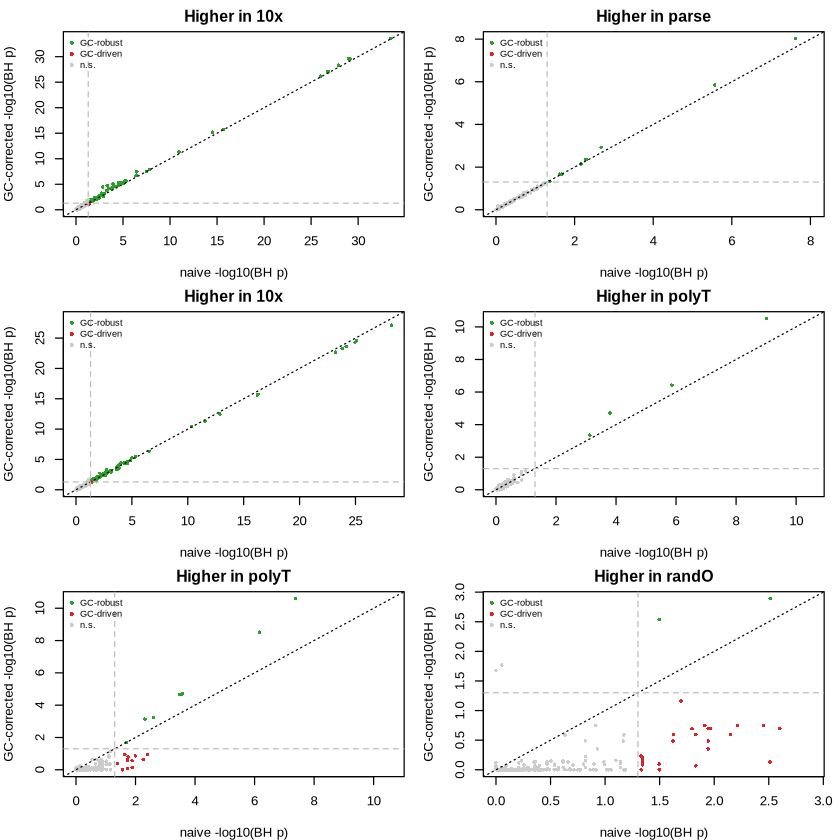

In [20]:
# --- Naive vs GC-corrected significance per comparison (below the diagonal = weakened by GC) ---
plot_side <- function(d, side) {
  xn <- -log10(pmax(d$padj_naive, 1e-300)); yw <- -log10(pmax(d$padj_wal, 1e-300))
  col <- ifelse(d$classification == "GC-robust", "#2ca02c",
         ifelse(d$classification == "GC-driven", "#d62728", "#cccccc"))
  lim <- max(c(xn, yw, 1))
  plot(xn, yw, col = col, pch = 16, cex = 0.6, xlim = c(0, lim), ylim = c(0, lim),
       xlab = "naive -log10(BH p)", ylab = "GC-corrected -log10(BH p)", main = paste("Higher in", side))
  abline(0, 1, lty = 3); abline(h = -log10(0.05), col = "grey", lty = 2)
  abline(v = -log10(0.05), col = "grey", lty = 2)
  legend("topleft", c("GC-robust", "GC-driven", "n.s."),
         col = c("#2ca02c", "#d62728", "#cccccc"), pch = 16, bty = "n", cex = 0.7)
}
par(mfrow = c(length(results_all), 2), mar = c(4, 4, 2, 1))
for (r in results_all) { plot_side(r$side1, r$name1); plot_side(r$side2, r$name2) }

# GC-robust (orthogonal) term counts per comparison
for (r in results_all) {
  cat(sprintf("\n%s vs %s — GC-robust terms:  %s=%d,  %s=%d\n",
      r$name1, r$name2,
      r$name1, sum(r$side1$classification == "GC-robust"),
      r$name2, sum(r$side2$classification == "GC-robust")))
}

### Bar plots (run in a Python kernel)

The GC-corrected enrichment bar plot reuses `_plot_term_enrichment_bar` via
`plotting.plot_goseq_enrichment_bar`. Run this in a **Python** notebook (e.g. any `human_edgepy.ipynb`),
pointing at each comparison folder — it reads the `goseq_gc_corrected.csv` files written above:

```python
from pathlib import Path
from XvP_utils import plotting
base = Path("/home/mcaskey/10XvParse/Notebooks/Comparisons")

plotting.plot_goseq_enrichment_bar(base / "10XvParse",   {"10x": "10X", "parse": "Parse"})
plotting.plot_goseq_enrichment_bar(base / "10XvPolyT",   {"10x": "10X", "polyT": "Parse 3'"})
plotting.plot_goseq_enrichment_bar(base / "PolyTvRandO", {"polyT": "Parse 3'", "randO": "Parse Random Oligo"})
```

Pass `pcol="padj_naive"` to plot the uncorrected version for side-by-side comparison.